# Ejercicio 1

Corrección de color de las imágenes en `./white_patch` usando un algoritmo *White Patch*

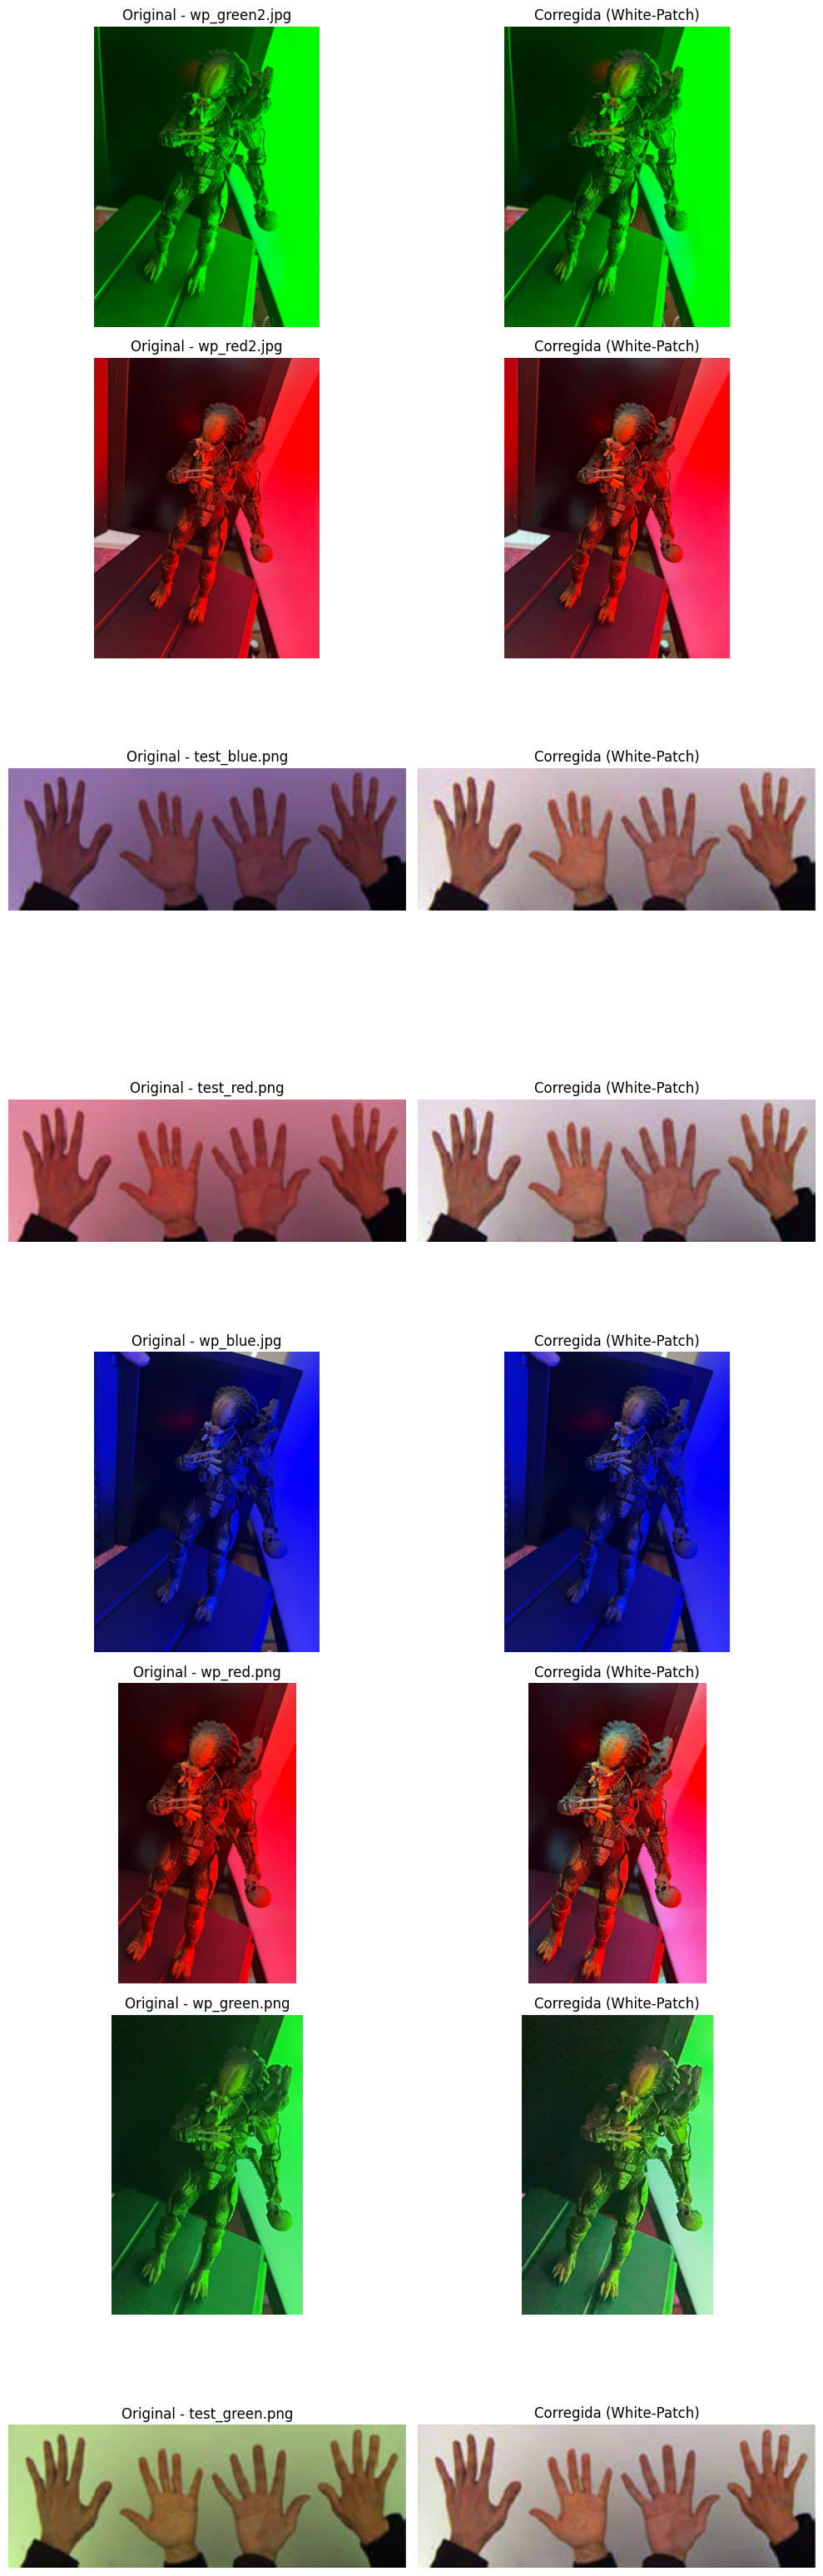

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

def white_patch(img):
    """
    Aplica el algoritmo White Patch para corrección de balance de blancos.
    Normaliza cada canal al valor máximo posible (255).
    """
    img = img.astype(np.float32)
    max_vals = img.reshape(-1, 3).max(axis=0)  # valores máximos por canal
    max_vals[max_vals == 0] = 1  # evitar división por cero
    corrected = img / max_vals * 255
    return np.clip(corrected, 0, 255).astype(np.uint8)

def load_images_from_folder(folder):
    """Carga todas las imágenes de un directorio."""
    images = []
    filenames = []
    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)
        if any(filename.lower().endswith(ext) for ext in ['.jpg', '.jpeg', '.png']):
            img = cv2.imread(path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img_rgb)
                filenames.append(filename)
    return images, filenames

def show_images_side_by_side(originals, corrected, titles):
    """Muestra imágenes en dos columnas: original (izquierda) y corregida (derecha)."""
    n = len(originals)
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(10, 4 * n))

    if n == 1:
        axes = [axes]  # caso especial de una sola imagen

    for i in range(n):
        # Imagen original
        axes[i][0].imshow(originals[i])
        axes[i][0].set_title(f"Original - {titles[i]}")
        axes[i][0].axis('off')

        # Imagen corregida
        axes[i][1].imshow(corrected[i])
        axes[i][1].set_title("Corregida (White-Patch)")
        axes[i][1].axis('off')

    plt.tight_layout()
    plt.show()

# === USO ===
folder_path = './white_patch'
originals, names = load_images_from_folder(folder_path)
corrected = [white_patch(img) for img in originals]

show_images_side_by_side(originals, corrected, names)


Se observa que el algoritmo funciona mejor cuando hay una referencia iluminada o que hubiera sido blanco originalmente antes de ser teñido por la luz para tomar una buena referencia de la corrección que se debe hacer. Cuando esta referencia no existe en la propia imagen el algoritmo no es capaz de compensar el canal de color más "oscuro". Como podemos ver a su vez, en los casos como en la imagen original-wp_red2, donde se tiene una saturación en la imagen, este algoritmo no funciona correctamente.

# Ejercicio 2

Cargar y visualizar las imágenes `img1_tp.png` y `img2_tp.png` en escala de grises. Luego obtener el histograma de cada una ajustando la cantidad de bins con el criterio decidido.

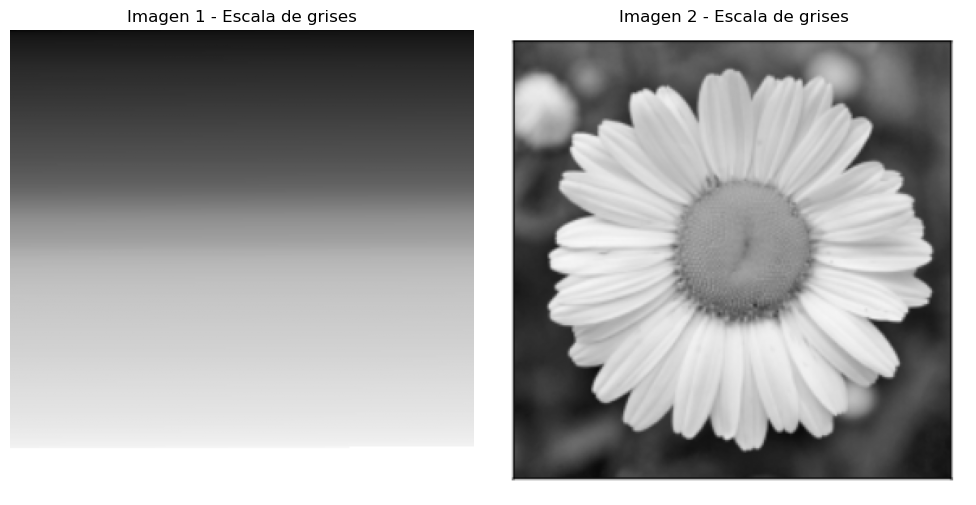

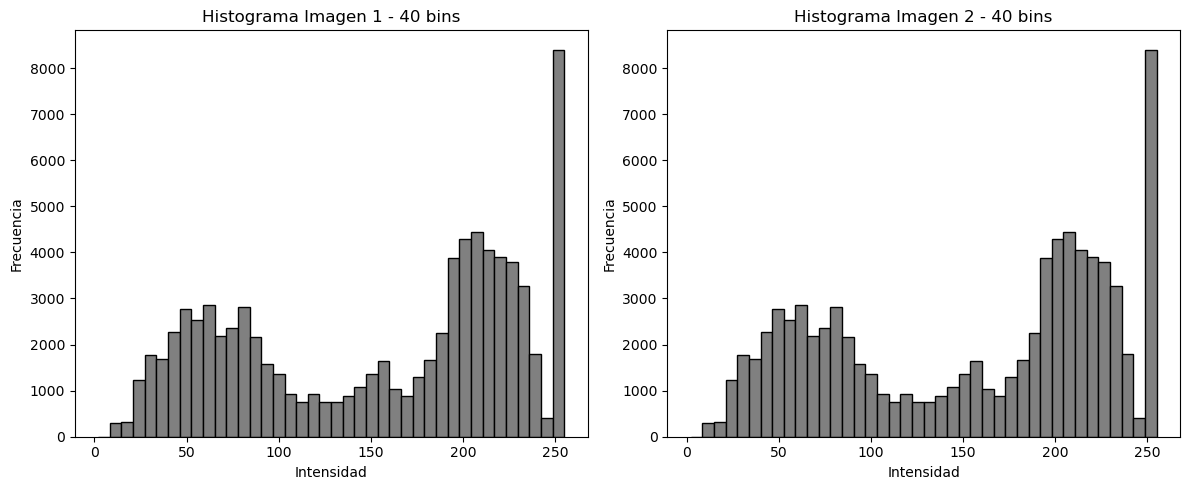

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# === Cargar imágenes en escala de grises ===
img1 = cv2.imread('img1_tp.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img2_tp.png', cv2.IMREAD_GRAYSCALE)

# === Mostrar las imágenes ===
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img1, cmap='gray')
axs[0].set_title("Imagen 1 - Escala de grises")
axs[0].axis('off')

axs[1].imshow(img2, cmap='gray')
axs[1].set_title("Imagen 2 - Escala de grises")
axs[1].axis('off')
plt.tight_layout()
plt.show()

# === Función para calcular número óptimo de bins (criterio de Freedman-Diaconis) ===
def compute_fd_bins(data):
    data = data.ravel()
    q75, q25 = np.percentile(data, [75 ,25])
    iqr = q75 - q25
    if iqr == 0:
        return 256  # fallback si no hay dispersión
    bin_width = 2 * iqr / np.cbrt(len(data))  # fórmula FD
    bins = int(np.ceil((data.max() - data.min()) / bin_width))
    return min(bins, 256)

# === Calcular histograma con bins óptimos ===
bins1 = compute_fd_bins(img1)
bins2 = compute_fd_bins(img2)

# === Graficar histogramas ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].hist(img1.ravel(), bins=bins1, color='gray', edgecolor='black')
axs[0].set_title(f"Histograma Imagen 1 - {bins1} bins")
axs[0].set_xlabel("Intensidad")
axs[0].set_ylabel("Frecuencia")

axs[1].hist(img2.ravel(), bins=bins2, color='gray', edgecolor='black')
axs[1].set_title(f"Histograma Imagen 2 - {bins2} bins")
axs[1].set_xlabel("Intensidad")
axs[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


Ambas imágenes parecen ser indistinguibles entre sí guiándose únicamente por los histogramas, ya que se pierde por completo la información posicional de los píxeles. El histograma podría ser útil para diferenciar objetos representados en imágenes que sean distinguibles por el color.

De tomar unicamente los histogramas de las imagenes, vemos como no es un elemento significativo para clasificación, a menos que se tenga una variación específica de algun aspecto como el color de los elementos a clasificar. Podemos ver como ambas imagenes presentan el mismo histograma, aunque una es simplemente un gradiente de colores, y la otra una imagen de una flor.